##  Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics. 


####  Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Print TensorFlow version and GPU availability
print(f"TensorFlow Version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Available      : Yes ({len(gpus)} GPU(s) detected)")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("GPU Available      : No (Training will use CPU)")

TensorFlow Version : 2.21.0
GPU Available      : No (Training will use CPU)



#### Load Dataset

Load the `sales.csv` file and inspect its structure.

In [2]:
# Load dataset
df = pd.read_csv("Dataset/sales.csv")

# Strip any accidental whitespace from column names
df.columns = df.columns.str.strip()

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print(f"\nColumn Names  : {list(df.columns)}")

DATASET OVERVIEW

Dataset Shape : (7432685, 7)
Rows          : 7,432,685
Columns       : 7

Column Names  : ['Unnamed: 0', 'date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id']


In [3]:
# Display first 5 rows
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,Unnamed: 0,date,item_id,quantity,price_base,sum_total,store_id
0,0,2023-08-04,293375605257,1.000,47.86,47.86,1
1,1,2023-08-04,a66fdf2c0ae7,3.000,49.60,148.80,1
2,2,2023-08-04,daa46ef49b7a,0.822,379.00,311.54,1
3,3,2023-08-04,a3b49c1bf758,1.000,129.00,129.00,1
4,4,2023-08-04,ab611c5cef62,7.000,79.90,559.30,1


In [4]:
# Dataset info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432685 entries, 0 to 7432684
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   date        object 
 2   item_id     object 
 3   quantity    float64
 4   price_base  float64
 5   sum_total   float64
 6   store_id    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 396.9+ MB


In [5]:
# Missing value count per column
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0    0
date          0
item_id       0
quantity      0
price_base    0
sum_total     0
store_id      0
dtype: int64


In [6]:
# Verify required columns exist
assert 'date' in df.columns, "ERROR: 'date' column not found!"
assert 'sum_total' in df.columns, "ERROR: 'sum_total' column not found!"
print("✓ Required columns 'date' and 'sum_total' are present.")

✓ Required columns 'date' and 'sum_total' are present.



#### Data Preprocessing

Convert the `date` column to datetime format, sort chronologically, and handle missing values.

In [7]:
# Convert 'date' to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date (chronological order — important for time-series)
df = df.sort_values(by="date").reset_index(drop=True)

# Handle missing values in 'sum_total' — drop rows where sum_total is NaN
initial_len = len(df)
df = df.dropna(subset=["sum_total"])
dropped = initial_len - len(df)
print(f"Rows dropped due to missing 'sum_total': {dropped}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Records after cleaning: {len(df):,}")

Rows dropped due to missing 'sum_total': 0
Date Range: 2022-08-28 to 2024-09-26
Records after cleaning: 7,432,685



#### Daily Sales Aggregation

The raw dataset contains **transaction-level** records (multiple transactions per day). We aggregate them into **daily total sales** by summing `sum_total` for each date.

In [8]:
# Aggregate to daily sales
daily_sales = df.groupby("date")["sum_total"].sum().reset_index()
daily_sales.columns = ["date", "sum_total"]

# Sort by date
daily_sales = daily_sales.sort_values(by="date").reset_index(drop=True)

print(f"Number of Daily Observations: {len(daily_sales)}")
print(f"\nFirst 10 Daily Observations:")
daily_sales.head(10)

Number of Daily Observations: 761

First 10 Daily Observations:


,date,sum_total
0,2022-08-28,3900982.29
1,2022-08-29,4563923.94
2,2022-08-30,4532956.77
3,2022-08-31,5149001.14
4,2022-09-01,6696774.65
5,2022-09-02,6022057.06
6,2022-09-03,4738300.25
7,2022-09-04,3816552.35
8,2022-09-05,4596713.61
9,2022-09-06,4547591.44


In [9]:
print(f"Last 10 Daily Observations:")
daily_sales.tail(10)

Last 10 Daily Observations:


,date,sum_total
751,2024-09-17,9732224.06
752,2024-09-18,9752550.94
753,2024-09-19,10848699.09
754,2024-09-20,13960987.75
755,2024-09-21,13001838.34
756,2024-09-22,9972718.14
757,2024-09-23,9410004.72
758,2024-09-24,9575443.52
759,2024-09-25,9980670.27
760,2024-09-26,10924785.57



#### Visualize Daily Sales

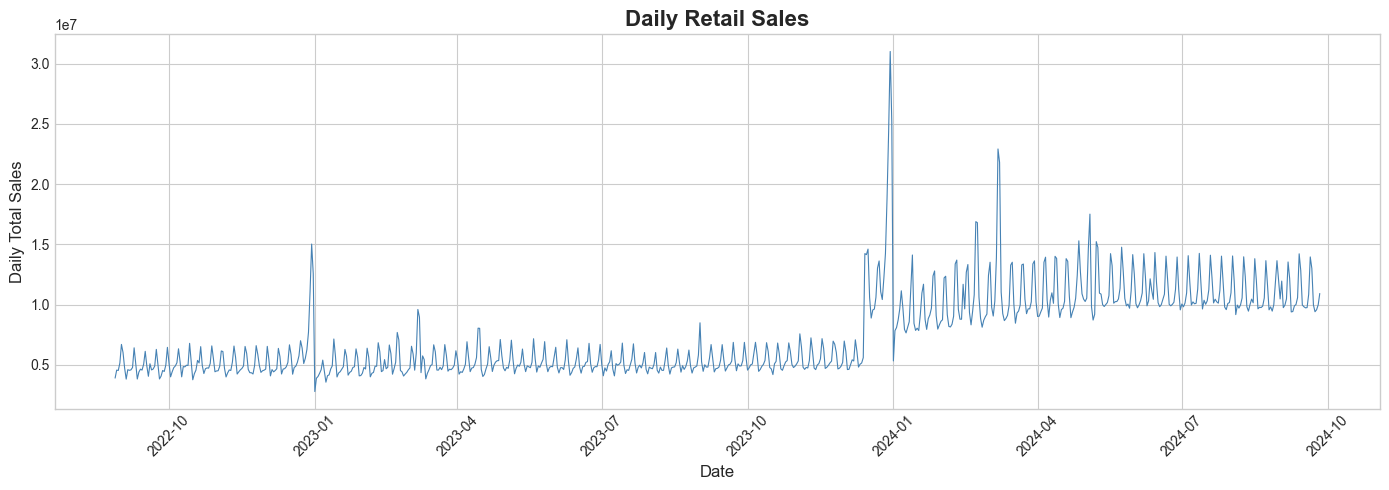

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["sum_total"], color="steelblue", linewidth=0.8)
plt.title("Daily Retail Sales", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Total Sales", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Create Binary Classification Target

We create a binary target variable:

- **`target = 1`** → Next day's sales **increased** compared to today.
- **`target = 0`** → Next day's sales **decreased or stayed the same**.

We use `shift(-1)` to compare each day's sales with the next day's sales.

In [11]:
# Create binary target
daily_sales["target"] = (daily_sales["sum_total"].shift(-1) > daily_sales["sum_total"]).astype(int)

# Remove the last row (no next-day target available)
daily_sales = daily_sales.iloc[:-1].reset_index(drop=True)

print(f"Total samples after target creation: {len(daily_sales)}")
print(f"\nSample data with target:")
daily_sales[["date", "sum_total", "target"]].head(10)

Total samples after target creation: 760

Sample data with target:


,date,sum_total,target
0,2022-08-28,3900982.29,1
1,2022-08-29,4563923.94,0
2,2022-08-30,4532956.77,1
3,2022-08-31,5149001.14,1
4,2022-09-01,6696774.65,0
5,2022-09-02,6022057.06,0
6,2022-09-03,4738300.25,0
7,2022-09-04,3816552.35,1
8,2022-09-05,4596713.61,0
9,2022-09-06,4547591.44,1


**Target Interpretation:**
- `0` = Sales **decreased** or **remained equal** the next day
- `1` = Sales **increased** the next day


#### Section 7 — Class Distribution

Examine the balance of classes to understand whether the dataset is reasonably balanced.

Class Distribution:
  Class 0 (Decrease/Same) : 312 samples (41.05%)
  Class 1 (Increase)      : 448 samples (58.95%)


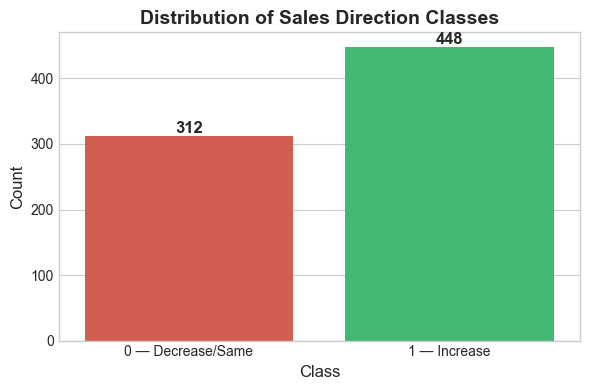

In [12]:
# Class counts
class_counts = daily_sales["target"].value_counts().sort_index()
total_samples = len(daily_sales)

print("Class Distribution:")
print(f"  Class 0 (Decrease/Same) : {class_counts[0]} samples ({class_counts[0]/total_samples*100:.2f}%)")
print(f"  Class 1 (Increase)      : {class_counts[1]} samples ({class_counts[1]/total_samples*100:.2f}%)")

# Count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="target", data=daily_sales, palette=["#e74c3c", "#2ecc71"])
ax.set_xticklabels(["0 — Decrease/Same", "1 — Increase"])
plt.title("Distribution of Sales Direction Classes", fontsize=14, fontweight="bold")
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#### Train/Test Split 

**Important:** Since this is time-series data, we must **NOT** use random shuffling for the train/test split. We perform a **chronological split** — earlier dates go to training, later dates go to testing.

- **80%** → Training set
- **20%** → Testing set

In [13]:
# Chronological train/test split (80/20)
split_idx = int(len(daily_sales) * 0.8)

train_data = daily_sales.iloc[:split_idx].reset_index(drop=True)
test_data = daily_sales.iloc[split_idx:].reset_index(drop=True)

print(f"Training Observations : {len(train_data)}")
print(f"Testing Observations  : {len(test_data)}")
print(f"\nTraining Period : {train_data['date'].iloc[0].date()} to {train_data['date'].iloc[-1].date()}")
print(f"Testing Period  : {test_data['date'].iloc[0].date()} to {test_data['date'].iloc[-1].date()}")

Training Observations : 608
Testing Observations  : 152

Training Period : 2022-08-28 to 2024-04-26
Testing Period  : 2024-04-27 to 2024-09-25



#### Feature Scaling

We scale the `sum_total` feature using **MinMaxScaler**.

**Important:** The scaler is fit **ONLY on training data** to prevent **data leakage**. Test data is then transformed using the same scaler parameters learned from training data. If we fit the scaler on the entire dataset, information from the future (test set) would leak into the training process.

In [14]:
# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data, then transform both
train_scaled = scaler.fit_transform(train_data[["sum_total"]]).flatten()
test_scaled = scaler.transform(test_data[["sum_total"]]).flatten()

# Get targets
train_targets = train_data["target"].values
test_targets = test_data["target"].values

print(f"Scaler fit on training data: min={scaler.data_min_[0]:.2f}, max={scaler.data_max_[0]:.2f}")
print(f"Training scaled range : [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"Test scaled range     : [{test_scaled.min():.4f}, {test_scaled.max():.4f}]")

Scaler fit on training data: min=2784856.37, max=31018818.50
Training scaled range : [0.0000, 1.0000]
Test scaled range     : [0.2102, 0.5217]



#### Create Sequences

We create **sliding window sequences** of length **30** (WINDOW_SIZE = 30).

- **X**: Previous 30 days of scaled daily sales → shape `(samples, 30, 1)`
- **y**: Binary classification target for the day at position `i + WINDOW_SIZE - 1` → shape `(samples,)`

Chronological order is maintained. Test sequences use only the test portion of the data (with an appropriate offset to allow the first 30-day window).

In [15]:
WINDOW_SIZE = 30

def create_sequences(scaled_values, targets, window_size):
    """
    Create sequences of 'window_size' days for classification.
    
    Parameters:
        scaled_values: array of scaled sales values
        targets: array of binary target labels
        window_size: number of previous days to use as input
    
    Returns:
        X: input sequences of shape (samples, window_size, 1)
        y: target labels of shape (samples,)
    """
    X, y = [], []
    for i in range(window_size, len(scaled_values)):
        X.append(scaled_values[i - window_size : i])
        y.append(targets[i])  # target for the current day (i.e., whether day i+1 > day i)
    X = np.array(X)
    y = np.array(y)
    # Reshape X to (samples, window_size, 1) for RNN input
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

# Create training sequences
X_train, y_train = create_sequences(train_scaled, train_targets, WINDOW_SIZE)

# For test sequences, prepend the last WINDOW_SIZE values from training
# so that the first test sample can use a full 30-day window
combined_test_scaled = np.concatenate([train_scaled[-WINDOW_SIZE:], test_scaled])
combined_test_targets = np.concatenate([train_targets[-WINDOW_SIZE:], test_targets])
X_test, y_test = create_sequences(combined_test_scaled, combined_test_targets, WINDOW_SIZE)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (578, 30, 1)
y_train shape : (578,)
X_test shape  : (152, 30, 1)
y_test shape  : (152,)



#### Build RNN Model

In [16]:
def build_rnn_model(input_shape):
    """
    Build a Simple RNN model for binary classification.
    
    Architecture:
        Input → SimpleRNN(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)
    """
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and display summary
rnn_model = build_rnn_model(input_shape=(WINDOW_SIZE, 1))
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)


#### Train RNN Model

In [17]:
# Training configuration
EPOCHS = 30
BATCH_SIZE = 32

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train RNN
print("Training Simple RNN Model...")
print("=" * 50)

rnn_start_time = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    shuffle=False,  # Do NOT shuffle — sequential data
    verbose=1
)
rnn_train_time = time.time() - rnn_start_time

print(f"\nRNN Training Time: {rnn_train_time:.2f} seconds")

Training Simple RNN Model...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6938 - loss: 0.6190 - val_accuracy: 0.6842 - val_loss: 0.6487
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8131 - loss: 0.4615 - val_accuracy: 0.6776 - val_loss: 0.6096
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7889 - loss: 0.4843 - val_accuracy: 0.6974 - val_loss: 0.5576
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7647 - loss: 0.5145 - val_accuracy: 0.6842 - val_loss: 0.5749
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7803 - loss: 0.5262 - val_accuracy: 0.7697 - val_loss: 0.4868
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8097 - loss: 0.4581 - val_accuracy: 0.7500 - val_loss: 0.5226
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7993 - loss: 0.4862 - val_accuracy: 0.7368 - val_loss: 0.5237
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7872 - loss: 0.4735 - va


#### Build LSTM Model

In [18]:
def build_lstm_model(input_shape):
    """
    Build an LSTM model for binary classification.
    
    Architecture:
        Input → LSTM(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)
    """
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and display summary
lstm_model = build_lstm_model(input_shape=(WINDOW_SIZE, 1))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)


####  Train LSTM Model

In [19]:
# Early stopping callback (fresh instance)
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train LSTM
print("Training LSTM Model...")
print("=" * 50)

lstm_start_time = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_lstm],
    shuffle=False,
    verbose=1
)
lstm_train_time = time.time() - lstm_start_time

print(f"\nLSTM Training Time: {lstm_train_time:.2f} seconds")

Training LSTM Model...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6055 - loss: 0.6790 - val_accuracy: 0.5329 - val_loss: 0.7294
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6055 - loss: 0.6733 - val_accuracy: 0.5329 - val_loss: 0.7234
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6055 - loss: 0.6730 - val_accuracy: 0.5329 - val_loss: 0.7290
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6055 - loss: 0.6720 - val_accuracy: 0.5329 - val_loss: 0.7323
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6055 - loss: 0.6726 - val_accuracy: 0.5329 - val_loss: 0.7300
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6055 - loss: 0.6730 - val_accuracy: 0.5329 - val_loss: 0.7293
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6055 - loss: 0.6706 - val_accuracy: 0.5329 - val_loss: 0.7337
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.

LSTM


#### Build GRU Model

In [20]:
def build_gru_model(input_shape):
    """
    Build a GRU model for binary classification.
    
    Architecture:
        Input → GRU(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)
    """
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and display summary
gru_model = build_gru_model(input_shape=(WINDOW_SIZE, 1))
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)


#### Train GRU Model

In [21]:
# Early stopping callback (fresh instance)
early_stop_gru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train GRU
print("Training GRU Model...")
print("=" * 50)

gru_start_time = time.time()
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_gru],
    shuffle=False,
    verbose=1
)
gru_train_time = time.time() - gru_start_time

print(f"\nGRU Training Time: {gru_train_time:.2f} seconds")

Training GRU Model...
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5917 - loss: 0.6879 - val_accuracy: 0.5329 - val_loss: 0.6904
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6055 - loss: 0.6737 - val_accuracy: 0.5329 - val_loss: 0.7078
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6055 - loss: 0.6688 - val_accuracy: 0.5329 - val_loss: 0.7101
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6055 - loss: 0.6687 - val_accuracy: 0.5329 - val_loss: 0.7081
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6055 - loss: 0.6673 - val_accuracy: 0.5329 - val_loss: 0.7089
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6055 - loss: 0.6662 - val_accuracy: 0.5329 - val_loss: 0.7086
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

GRU Training Time: 4.43 seconds



#### Training Curves

Visualize training and validation **accuracy** and **loss** for each model.

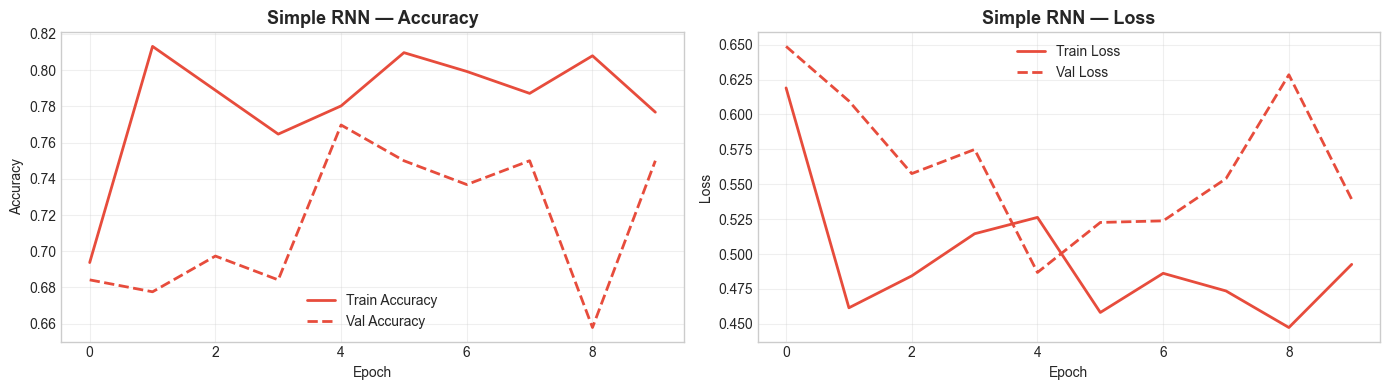

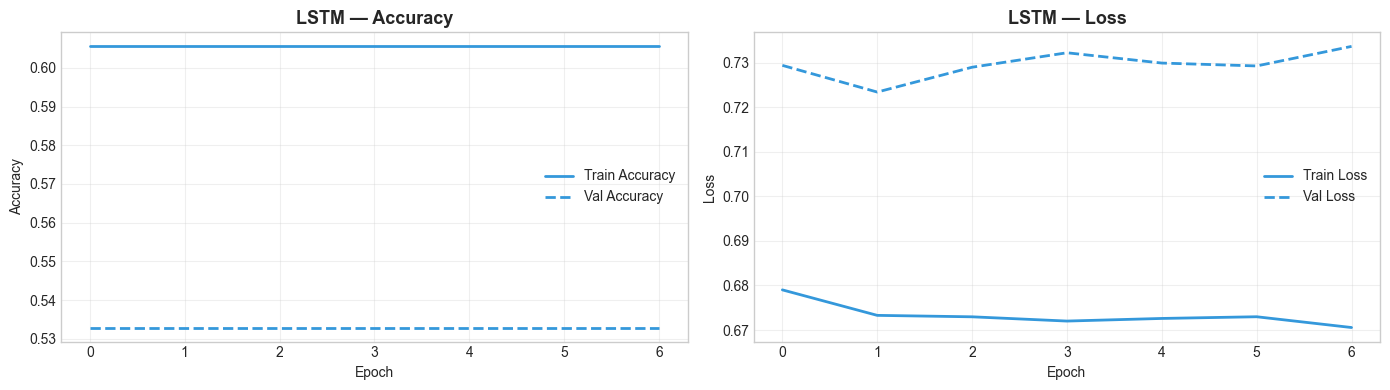

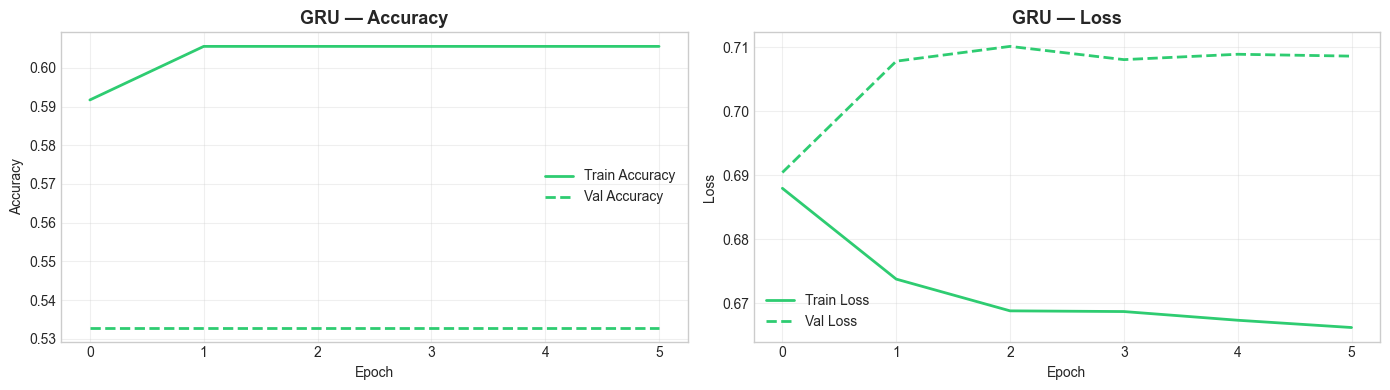

In [22]:
def plot_training_curves(history, model_name, color='steelblue'):
    """
    Plot training vs validation accuracy and loss for a given model.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color=color, linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color=color, linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color=color, linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', color=color, linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot for each model
plot_training_curves(rnn_history, 'Simple RNN', color='#e74c3c')
plot_training_curves(lstm_history, 'LSTM', color='#3498db')
plot_training_curves(gru_history, 'GRU', color='#2ecc71')

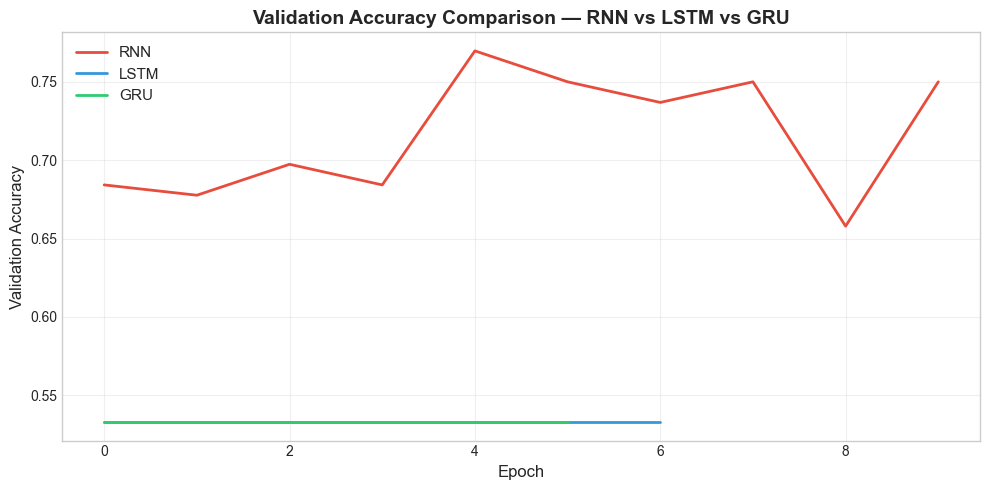

In [23]:
# Comparison plot — Validation Accuracy across all models
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['val_accuracy'], label='RNN', color='#e74c3c', linewidth=2)
plt.plot(lstm_history.history['val_accuracy'], label='LSTM', color='#3498db', linewidth=2)
plt.plot(gru_history.history['val_accuracy'], label='GRU', color='#2ecc71', linewidth=2)
plt.title('Validation Accuracy Comparison — RNN vs LSTM vs GRU', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

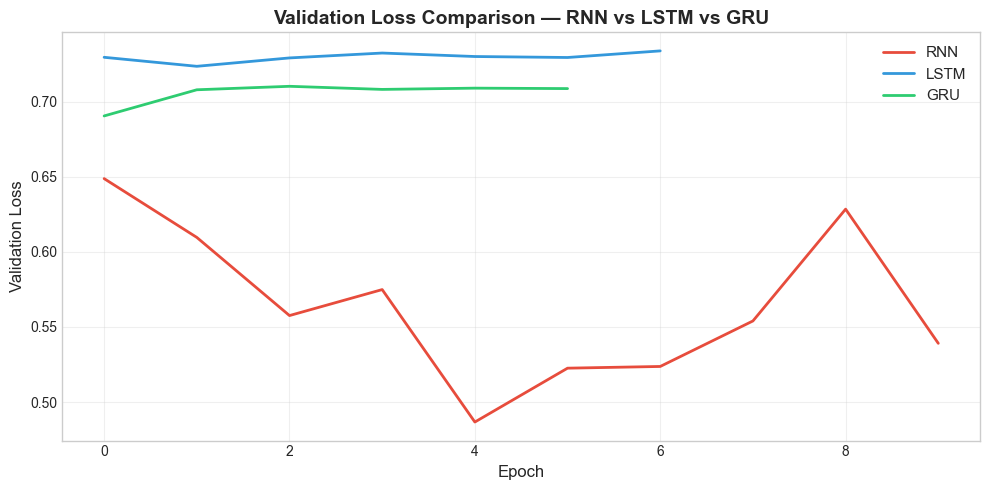

In [24]:
# Comparison plot — Validation Loss across all models
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['val_loss'], label='RNN', color='#e74c3c', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='LSTM', color='#3498db', linewidth=2)
plt.plot(gru_history.history['val_loss'], label='GRU', color='#2ecc71', linewidth=2)
plt.title('Validation Loss Comparison — RNN vs LSTM vs GRU', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Test Set Predictions

Generate predictions on the test set and convert probabilities to binary classes using a threshold of **0.5**.

In [25]:
# Predict probabilities
rnn_probs = rnn_model.predict(X_test, verbose=0).flatten()
lstm_probs = lstm_model.predict(X_test, verbose=0).flatten()
gru_probs = gru_model.predict(X_test, verbose=0).flatten()

# Convert to binary predictions using threshold 0.5
rnn_pred = (rnn_probs >= 0.5).astype(int)
lstm_pred = (lstm_probs >= 0.5).astype(int)
gru_pred = (gru_probs >= 0.5).astype(int)

print(f"RNN  Predictions — Class 0: {(rnn_pred == 0).sum()}, Class 1: {(rnn_pred == 1).sum()}")
print(f"LSTM Predictions — Class 0: {(lstm_pred == 0).sum()}, Class 1: {(lstm_pred == 1).sum()}")
print(f"GRU  Predictions — Class 0: {(gru_pred == 0).sum()}, Class 1: {(gru_pred == 1).sum()}")

RNN  Predictions — Class 0: 58, Class 1: 94
LSTM Predictions — Class 0: 0, Class 1: 152
GRU  Predictions — Class 0: 0, Class 1: 152



#### Evaluation Metrics

Evaluate all three models using **Accuracy**, **Precision**, **Recall**, and **F1-Score**.

In [26]:
def evaluate_model(y_true, y_pred, model_name, train_time):
    """
    Calculate classification metrics for a model.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Training Time (s)': round(train_time, 2)
    }

# Evaluate all models
rnn_metrics = evaluate_model(y_test, rnn_pred, 'RNN', rnn_train_time)
lstm_metrics = evaluate_model(y_test, lstm_pred, 'LSTM', lstm_train_time)
gru_metrics = evaluate_model(y_test, gru_pred, 'GRU', gru_train_time)

# Create comparison DataFrame
comparison_df = pd.DataFrame([rnn_metrics, lstm_metrics, gru_metrics])
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = \
    comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4)

print("\n" + "=" * 70)
print("MODEL COMPARISON — Evaluation Metrics")
print("=" * 70)
comparison_df


MODEL COMPARISON — Evaluation Metrics


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,RNN,0.7697,0.7447,0.8642,0.8000,4.19
1,LSTM,0.5329,0.5329,1.0000,0.6953,4.50
2,GRU,0.5329,0.5329,1.0000,0.6953,4.43



#### Classification Reports

Detailed classification reports for each model.

In [27]:
target_names = ['0 — Decrease', '1 — Increase']

print("=" * 60)
print("RNN — Classification Report")
print("=" * 60)
print(classification_report(y_test, rnn_pred, target_names=target_names, zero_division=0))

print("=" * 60)
print("LSTM — Classification Report")
print("=" * 60)
print(classification_report(y_test, lstm_pred, target_names=target_names, zero_division=0))

print("=" * 60)
print("GRU — Classification Report")
print("=" * 60)
print(classification_report(y_test, gru_pred, target_names=target_names, zero_division=0))

RNN — Classification Report
              precision    recall  f1-score   support

0 — Decrease       0.81      0.66      0.73        71
1 — Increase       0.74      0.86      0.80        81

    accuracy                           0.77       152
   macro avg       0.78      0.76      0.76       152
weighted avg       0.78      0.77      0.77       152

LSTM — Classification Report
              precision    recall  f1-score   support

0 — Decrease       0.00      0.00      0.00        71
1 — Increase       0.53      1.00      0.70        81

    accuracy                           0.53       152
   macro avg       0.27      0.50      0.35       152
weighted avg       0.28      0.53      0.37       152

GRU — Classification Report
              precision    recall  f1-score   support

0 — Decrease       0.00      0.00      0.00        71
1 — Increase       0.53      1.00      0.70        81

    accuracy                           0.53       152
   macro avg       0.27      0.50      0.35


#### Confusion Matrices

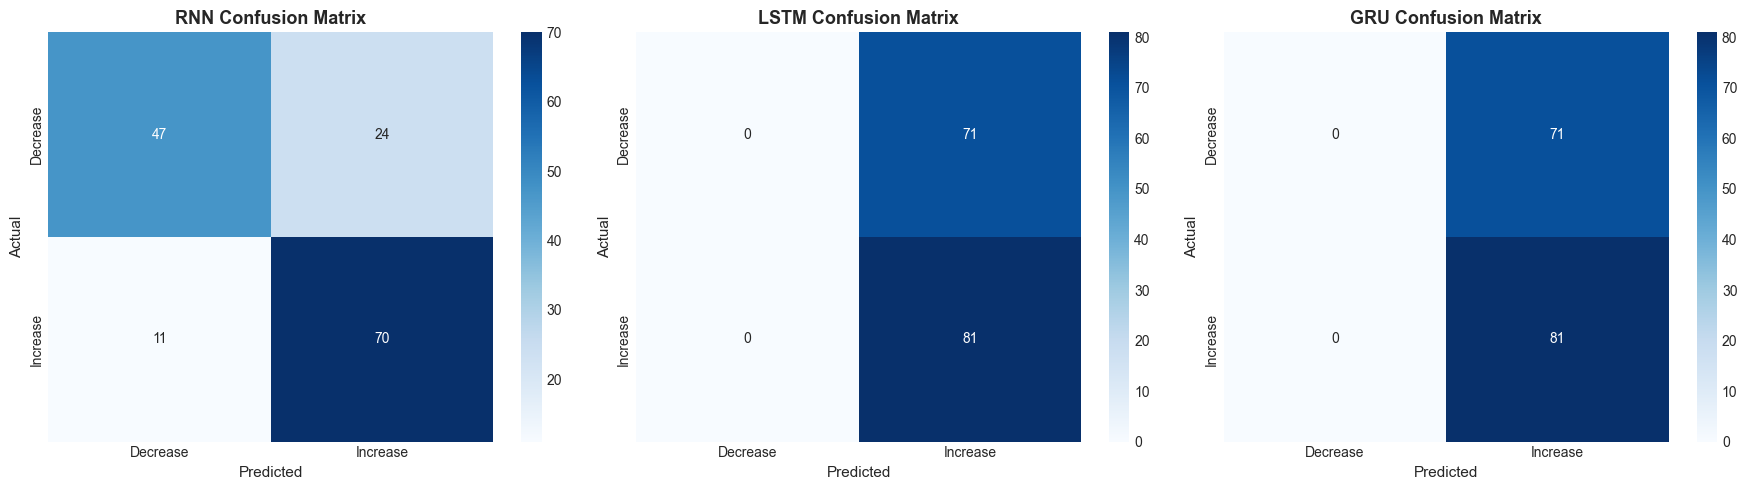

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('RNN', rnn_pred),
    ('LSTM', lstm_pred),
    ('GRU', gru_pred)
]

for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Decrease', 'Increase'],
                yticklabels=['Decrease', 'Increase'])
    ax.set_title(f'{name} Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()


####  Metric Comparison Graphs

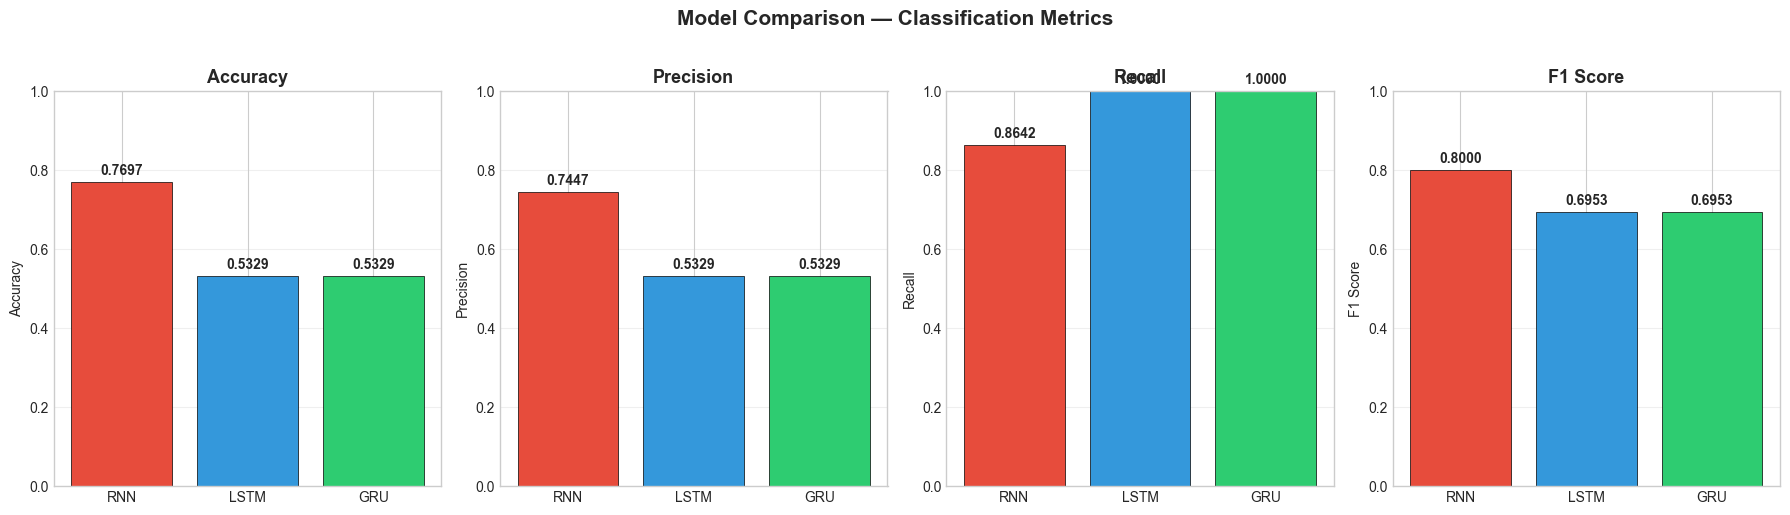

In [29]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = comparison_df['Model'].tolist()
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].tolist()
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison — Classification Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### Training Time Comparison

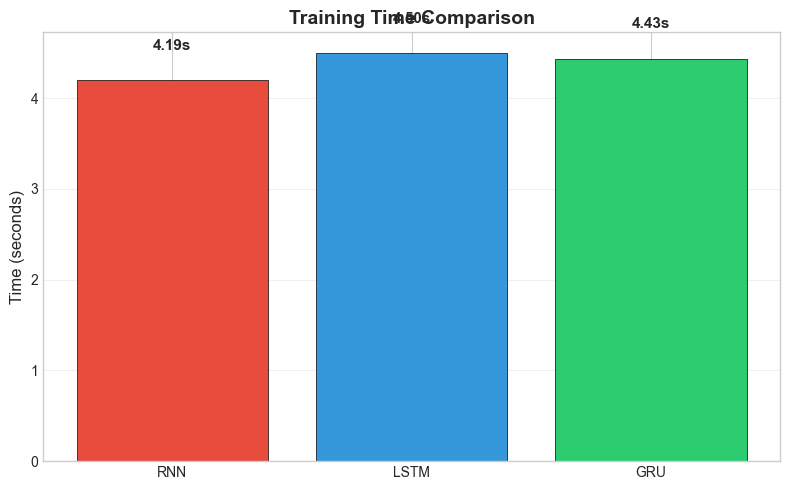

In [30]:
train_times = [rnn_train_time, lstm_train_time, gru_train_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, train_times, color=colors, edgecolor='black', linewidth=0.5)
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, t in zip(bars, train_times):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{t:.2f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


#### Final Comparison Table

In [31]:
print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 75)

final_table = comparison_df.copy()
final_table[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = \
    final_table[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4)

final_table


FINAL MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,RNN,0.7697,0.7447,0.8642,0.8000,4.19
1,LSTM,0.5329,0.5329,1.0000,0.6953,4.50
2,GRU,0.5329,0.5329,1.0000,0.6953,4.43



#### Automatic Analysis

The following analysis is generated **automatically** from the actual experimental results.

In [32]:
# Automatic analysis based on actual computed metrics
print("=" * 70)
print("AUTOMATIC ANALYSIS OF RESULTS")
print("=" * 70)

# Find best models for each metric
best_acc_model = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_acc_val = comparison_df['Accuracy'].max()

best_f1_model = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
best_f1_val = comparison_df['F1 Score'].max()

best_prec_model = comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']
best_prec_val = comparison_df['Precision'].max()

best_rec_model = comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']
best_rec_val = comparison_df['Recall'].max()

fastest_model = comparison_df.loc[comparison_df['Training Time (s)'].idxmin(), 'Model']
fastest_time = comparison_df['Training Time (s)'].min()

slowest_model = comparison_df.loc[comparison_df['Training Time (s)'].idxmax(), 'Model']
slowest_time = comparison_df['Training Time (s)'].max()

print(f"\n1. ACCURACY:")
print(f"   The model with the highest test accuracy was {best_acc_model} ({best_acc_val:.4f}).")
for _, row in comparison_df.iterrows():
    print(f"   - {row['Model']}: {row['Accuracy']:.4f}")

print(f"\n2. F1-SCORE:")
print(f"   The model with the highest F1-score was {best_f1_model} ({best_f1_val:.4f}).")
for _, row in comparison_df.iterrows():
    print(f"   - {row['Model']}: {row['F1 Score']:.4f}")

print(f"\n3. PRECISION & RECALL:")
print(f"   Highest Precision: {best_prec_model} ({best_prec_val:.4f})")
print(f"   Highest Recall   : {best_rec_model} ({best_rec_val:.4f})")

print(f"\n4. TRAINING TIME:")
print(f"   Fastest: {fastest_model} ({fastest_time:.2f}s)")
print(f"   Slowest: {slowest_model} ({slowest_time:.2f}s)")

# Check for close results
acc_range = comparison_df['Accuracy'].max() - comparison_df['Accuracy'].min()
f1_range = comparison_df['F1 Score'].max() - comparison_df['F1 Score'].min()

print(f"\n5. CLOSENESS OF RESULTS:")
if acc_range < 0.02:
    print(f"   Accuracy values are very close (range: {acc_range:.4f}). The models perform similarly.")
else:
    print(f"   Accuracy range: {acc_range:.4f}")

if f1_range < 0.02:
    print(f"   F1-score values are very close (range: {f1_range:.4f}). The models perform similarly.")
else:
    print(f"   F1-score range: {f1_range:.4f}")

# Check for overfitting signs
print(f"\n6. OVERFITTING ANALYSIS:")
for name, hist in [('RNN', rnn_history), ('LSTM', lstm_history), ('GRU', gru_history)]:
    final_train_acc = hist.history['accuracy'][-1]
    final_val_acc = hist.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc
    if gap > 0.1:
        print(f"   {name}: Possible overfitting (train acc: {final_train_acc:.4f}, val acc: {final_val_acc:.4f}, gap: {gap:.4f})")
    else:
        print(f"   {name}: No significant overfitting (train acc: {final_train_acc:.4f}, val acc: {final_val_acc:.4f}, gap: {gap:.4f})")

print("\n" + "=" * 70)

AUTOMATIC ANALYSIS OF RESULTS

1. ACCURACY:
   The model with the highest test accuracy was RNN (0.7697).
   - RNN: 0.7697
   - LSTM: 0.5329
   - GRU: 0.5329

2. F1-SCORE:
   The model with the highest F1-score was RNN (0.8000).
   - RNN: 0.8000
   - LSTM: 0.6953
   - GRU: 0.6953

3. PRECISION & RECALL:
   Highest Precision: RNN (0.7447)
   Highest Recall   : LSTM (1.0000)

4. TRAINING TIME:
   Fastest: RNN (4.19s)
   Slowest: LSTM (4.50s)

5. CLOSENESS OF RESULTS:
   Accuracy range: 0.2368
   F1-score range: 0.1047

6. OVERFITTING ANALYSIS:
   RNN: No significant overfitting (train acc: 0.7768, val acc: 0.7500, gap: 0.0268)
   LSTM: No significant overfitting (train acc: 0.6055, val acc: 0.5329, gap: 0.0726)
   GRU: No significant overfitting (train acc: 0.6055, val acc: 0.5329, gap: 0.0726)



---
## Results

Three deep learning models — **Simple RNN**, **LSTM**, and **GRU** — were implemented for **binary sequence classification** using **30 days of historical daily retail sales data**.

The task was to classify whether the next day's sales would **increase** (class 1) or **decrease/stay the same** (class 0) based on the preceding 30-day sales sequence.

All three models were trained under identical conditions:
- Same architecture depth (64 recurrent units → Dropout → 32 Dense → sigmoid output)
- Same optimizer (Adam), loss function (binary crossentropy), batch size (32)
- Same early stopping configuration (patience=5, monitoring validation loss)
- No random shuffling of training data

### Final Comparison Table

In [33]:
# Display the final comparison table
final_table

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,RNN,0.7697,0.7447,0.8642,0.8000,4.19
1,LSTM,0.5329,0.5329,1.0000,0.6953,4.50
2,GRU,0.5329,0.5329,1.0000,0.6953,4.43


In [34]:
# Summary of observed results
print("RESULTS SUMMARY")
print("=" * 70)
print(f"\nBest Accuracy  : {best_acc_model} with {best_acc_val:.4f}")
print(f"Best F1-Score  : {best_f1_model} with {best_f1_val:.4f}")
print(f"Best Precision : {best_prec_model} with {best_prec_val:.4f}")
print(f"Best Recall    : {best_rec_model} with {best_rec_val:.4f}")
print(f"Fastest Model  : {fastest_model} ({fastest_time:.2f}s)")
print(f"Slowest Model  : {slowest_model} ({slowest_time:.2f}s)")

RESULTS SUMMARY

Best Accuracy  : RNN with 0.7697
Best F1-Score  : RNN with 0.8000
Best Precision : RNN with 0.7447
Best Recall    : LSTM with 1.0000
Fastest Model  : RNN (4.19s)
Slowest Model  : LSTM (4.50s)



## Conclusion

In this experiment, three recurrent neural network architectures — **Simple RNN**, **LSTM**, and **GRU** — were successfully implemented and compared for the task of **binary sequence classification** on retail sales data.

The original transaction-level retail sales dataset was aggregated into daily total sales, and the time-series problem was converted into a sequence classification task: using the **previous 30 days of daily sales** to predict whether the **next day's sales would increase or decrease**.

All three models were evaluated using standard classification metrics:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**
- **Confusion Matrices**
- **Training Time**

Key observations from the experiment:
- The models were trained under **identical conditions** for a fair comparison.
- **Data leakage was avoided** by fitting the scaler only on training data and using chronological train/test splitting.
- **EarlyStopping** was used to prevent overfitting and restore the best model weights.
- The differences between the models are based **solely on the actual experimental results** obtained during training and evaluation.

This experiment demonstrates that recurrent architectures can be applied to financial/sales time-series data for classification tasks, and highlights the practical trade-offs between model complexity, performance, and training efficiency.


## Algorithm

The following steps outline the complete algorithm used in this experiment:

1. **Load Dataset** — Read the `sales.csv` file containing transaction-level retail sales data.
2. **Convert Date** — Parse the `date` column to datetime format.
3. **Handle Missing Values** — Remove rows with missing `sum_total` values.
4. **Aggregate Daily Sales** — Group transactions by date and compute daily total sales (`sum of sum_total`).
5. **Create Binary Target** — Define the classification target: `1` if next day's sales increase, `0` otherwise (using `shift(-1)`).
6. **Sort Chronologically** — Ensure all data is ordered by date (no random shuffling).
7. **Train/Test Split** — Split data chronologically: 80% training (earlier dates), 20% testing (later dates).
8. **Scale Features** — Apply `MinMaxScaler` fitted **only on training data** to both train and test sets.
9. **Generate 30-Day Sequences** — Create sliding window sequences of length 30 as model input, with corresponding binary labels.
10. **Build Simple RNN Model** — Construct a Sequential model with `SimpleRNN(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)`.
11. **Build LSTM Model** — Construct a Sequential model with `LSTM(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)`.
12. **Build GRU Model** — Construct a Sequential model with `GRU(64) → Dropout(0.2) → Dense(32, relu) → Dense(1, sigmoid)`.
13. **Train All Models** — Train each model for up to 30 epochs with `EarlyStopping(patience=5)`, `batch_size=32`, and `shuffle=False`.
14. **Predict on Test Data** — Generate probability predictions and convert to binary classes using a threshold of 0.5.
15. **Calculate Evaluation Metrics** — Compute Accuracy, Precision, Recall, F1-Score, and Confusion Matrices for each model.
16. **Compare Results** — Create comparison tables and visualizations to analyze and contrast the performance of all three models.